# <span style="color:purple"> NPAC Cloud Properties :


### <span style="color:purple"> Imports

In [1]:
import utils
from utils.load_variable import load_variables_for_all_years
from matplotlib import pyplot as plt
import xarray as xr
import calendar
import numpy as np
import seaborn as sns
from scipy.stats import ttest_1samp
import matplotlib.pyplot as plt
import calendar
import wesanderson

### <span style="color:purple"> Loading Variables

In [2]:
CDNUMC = load_variables_for_all_years('h0', 'CDNUMC')
TGCLDLWP = load_variables_for_all_years('h0', 'TGCLDLWP')

area = xr.open_dataarray('/glade/work/jzweifel/Regional_Masks_And_Area/area_files/AREA.nc')
NPAC_bool = xr.open_dataarray('/glade/work/jzweifel/Regional_Masks_And_Area/masks/NPAC/NPAC_mask.nc')
w = area.where(NPAC_bool, 0)

### <span style="color:purple"> area weighted monthly climatology helper function

In [3]:
def npac_monthly_climatology(da, w_area):
    # NPAC area-weighted mean time series
    ts = da.weighted(w_area).mean(['lat', 'lon'])

    # monthly climatology (month=1..12)
    clim = ts.groupby('time.month').mean('time').roll(month=-1)

    return clim

### <span style="color:purple"> Plotting LWP and CDNUMC

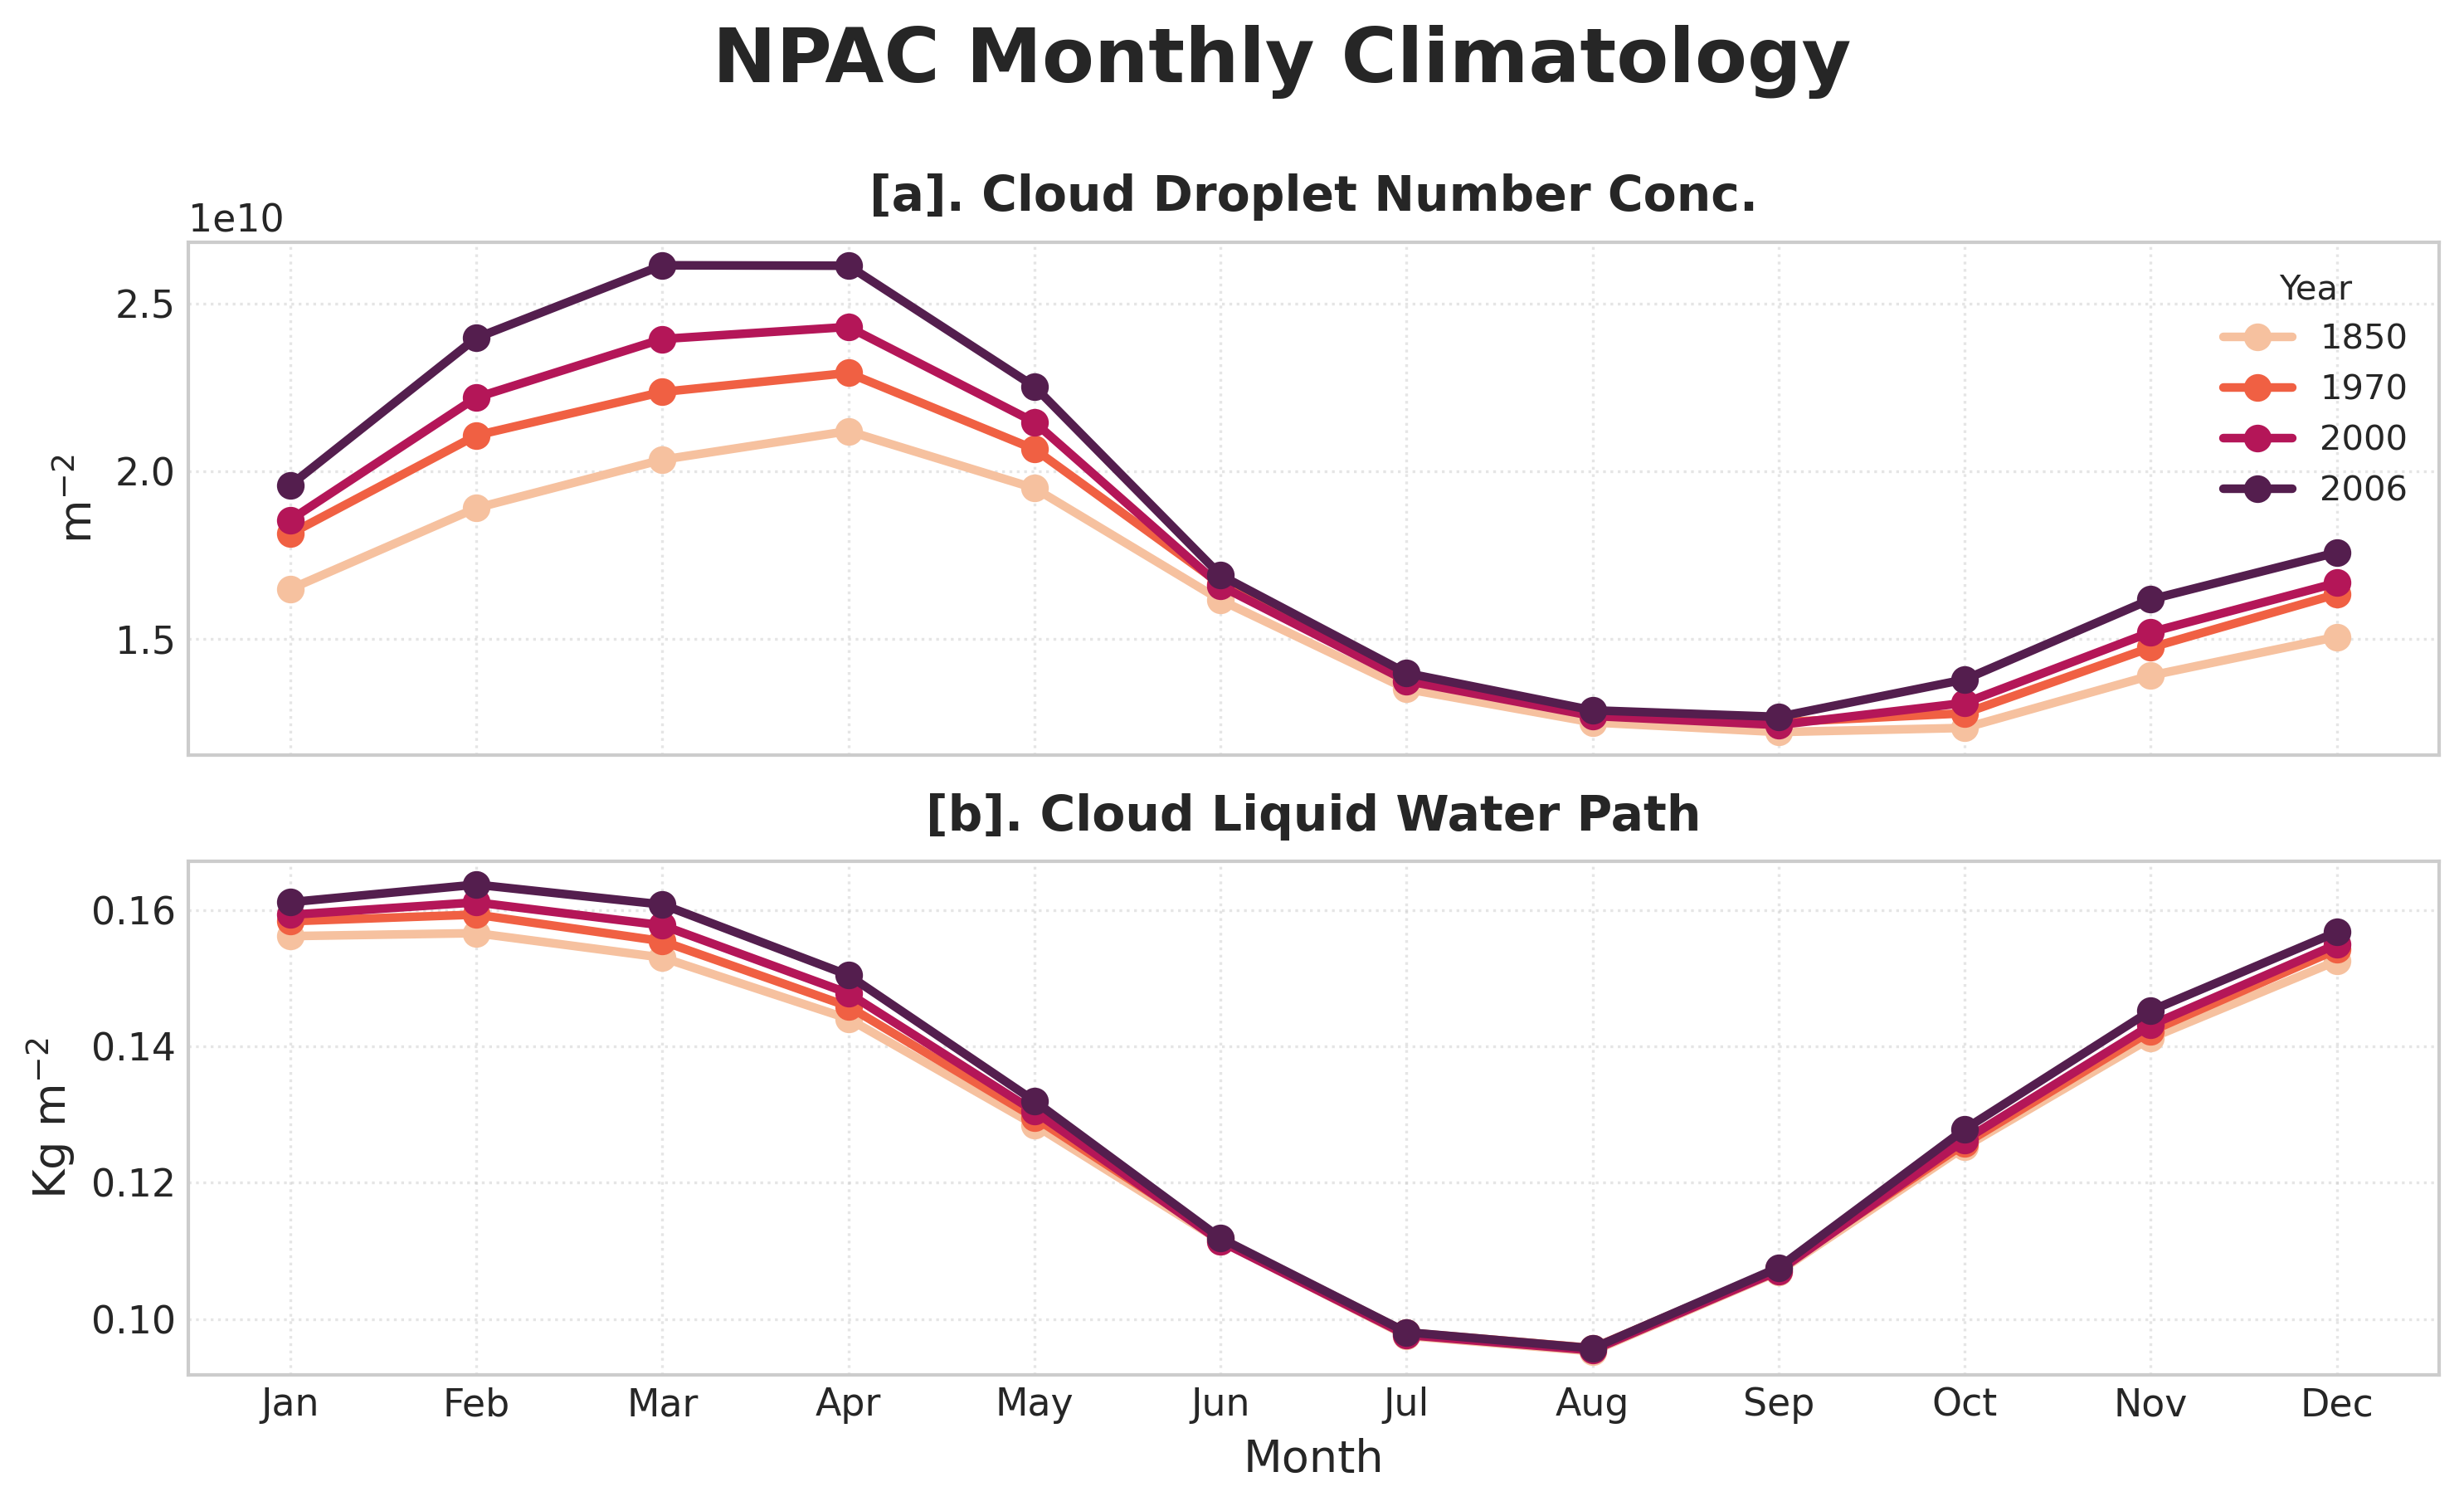

In [4]:
years = ["1850", "1970", "2000", "2006"]
months = [calendar.month_abbr[i] for i in range(1, 13)]

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"legend.frameon": False, "lines.linewidth": 2.5, "axes.titleweight": "bold", "axes.labelsize": 13, "xtick.labelsize": 11,"ytick.labelsize": 11,})

palette = sns.color_palette("rocket", 8)[::-2]
color_for = dict(zip(years, palette[:4]))

cdnumc_clim = {k: npac_monthly_climatology(CDNUMC[k], w) for k in years}
lwp_clim    = {k: npac_monthly_climatology(TGCLDLWP[k], w) for k in years}

# Figure
# ----------------------------
fig, axes = plt.subplots(2, 1, figsize=(10, 6), dpi=300, sharex=True)

# ----- (a) CDNUMC -----
ax1 = axes[0]
for k in years:
    ax1.plot(months, cdnumc_clim[k].values, label=k, color=color_for[k], marker="o", markersize=7)

ax1.set_ylabel("m$^{-2}$")
ax1.set_title("[a]. Cloud Droplet Number Conc.", fontsize=14, y=1.02)
ax1.grid(linestyle=":", alpha=0.5)
ax1.ticklabel_format(style="sci", axis="y", scilimits=(0, 0))

# one clean legend (top panel)
ax1.legend(title="Year", loc="upper right", fontsize=10, title_fontsize=10)

# ----- (b) TGCLDLWP -----
ax2 = axes[1]
for k in years:
    ax2.plot(months, lwp_clim[k].values, color=color_for[k], marker="o", markersize=7)

ax2.set_ylabel("Kg m$^{-2}$")
ax2.set_title("[b]. Cloud Liquid Water Path", fontsize=14, y=1.02)
ax2.set_xlabel("Month")
ax2.grid(linestyle=":", alpha=0.5)


# Suptitle + spacing
# ----------------------------
fig.suptitle("NPAC Monthly Climatology", fontsize=22, weight="bold", x=0.52, y=1.0)

plt.tight_layout()
#plt.subplots_adjust(top=0.90)
#plt.savefig('/glade/u/home/jzweifel/jupyter_workspaces/Masters_paper_analysis/notebooks/saved_figures_pngs/Figure_09.png')

plt.show()